In [ ]:
# Level 1 Task 1- Data Cleaning and Preprocessing 

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('churn-bigml-80.csv')

In [2]:
# Initial inspection
print("BEFORE CLEANING")
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

BEFORE CLEANING
Shape: (2666, 20)

Data types:
 State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Missing values per column:
 State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total

In [5]:
# Handle missing values
# No missing values were found, but this is how you'd handle them if present:
# Numeric columns -> fill with median; Categorical -> fill with mode
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
# --- Remove duplicate rows ---
df = df.drop_duplicates()

In [7]:
# Standardize inconsistent formats 
# Strip whitespace from string/categorical columns
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    df[col] = df[col].str.strip()

# Standardize categorical text casing (e.g., "Yes"/"No" columns)
df['International plan'] = df['International plan'].str.capitalize()
df['Voice mail plan'] = df['Voice mail plan'].str.capitalize()

# Convert Churn to a clean boolean/int for later modeling convenience
df['Churn'] = df['Churn'].astype(bool)

In [9]:
#  After cleaning 
print("\nAFTER CLEANING")
print("Shape:", df.shape)
print("Missing values total:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nUnique values check:")
print("International plan:", df['International plan'].unique())
print("Voice mail plan:", df['Voice mail plan'].unique())
print("Churn dtype:", df['Churn'].dtype)

# Save cleaned version for use in later tasks
df.to_csv('churn_cleaned.csv', index=False)


AFTER CLEANING
Shape: (2666, 20)
Missing values total: 0
Duplicate rows: 0

Unique values check:
International plan: ['No' 'Yes']
Voice mail plan: ['Yes' 'No']
Churn dtype: bool


In [ ]:
# Level 1 Task 2- Exploratory Data Analysis (EDA)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Summary statistics 
print("SUMMARY STATISTICS (numerical columns)")
print(df.describe().T)  # .T transposes so stats are easier to read per column

print("\nMODE of numerical columns:")
print(df.select_dtypes(include='number').mode().iloc[0])

print("\nChurn value counts:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100) 

SUMMARY STATISTICS (numerical columns)
                         count        mean        std     min       25%  \
Account length          2666.0  100.620405  39.563974    1.00   73.0000   
Area code               2666.0  437.438860  42.521018  408.00  408.0000   
Number vmail messages   2666.0    8.021755  13.612277    0.00    0.0000   
Total day minutes       2666.0  179.481620  54.210350    0.00  143.4000   
Total day calls         2666.0  100.310203  19.988162    0.00   87.0000   
Total day charge        2666.0   30.512404   9.215733    0.00   24.3800   
Total eve minutes       2666.0  200.386159  50.951515    0.00  165.3000   
Total eve calls         2666.0  100.023631  20.161445    0.00   87.0000   
Total eve charge        2666.0   17.033072   4.330864    0.00   14.0500   
Total night minutes     2666.0  201.168942  50.780323   43.70  166.9250   
Total night calls       2666.0  100.106152  19.418459   33.00   87.0000   
Total night charge      2666.0    9.052689   2.285120    1.97

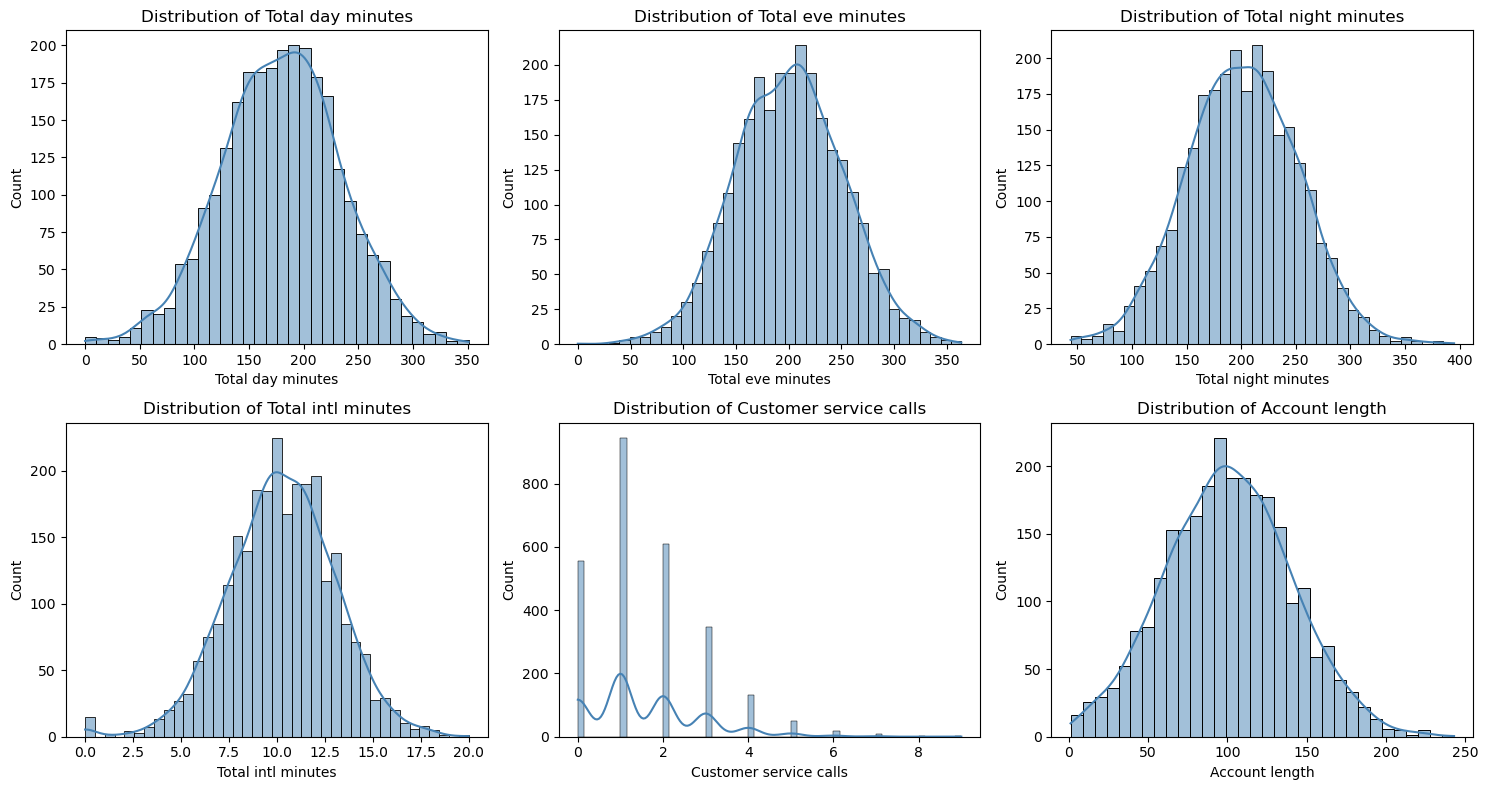

In [12]:
# Distribution plots (histograms) 
num_cols = ['Total day minutes', 'Total eve minutes', 'Total night minutes',
            'Total intl minutes', 'Customer service calls', 'Account length']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

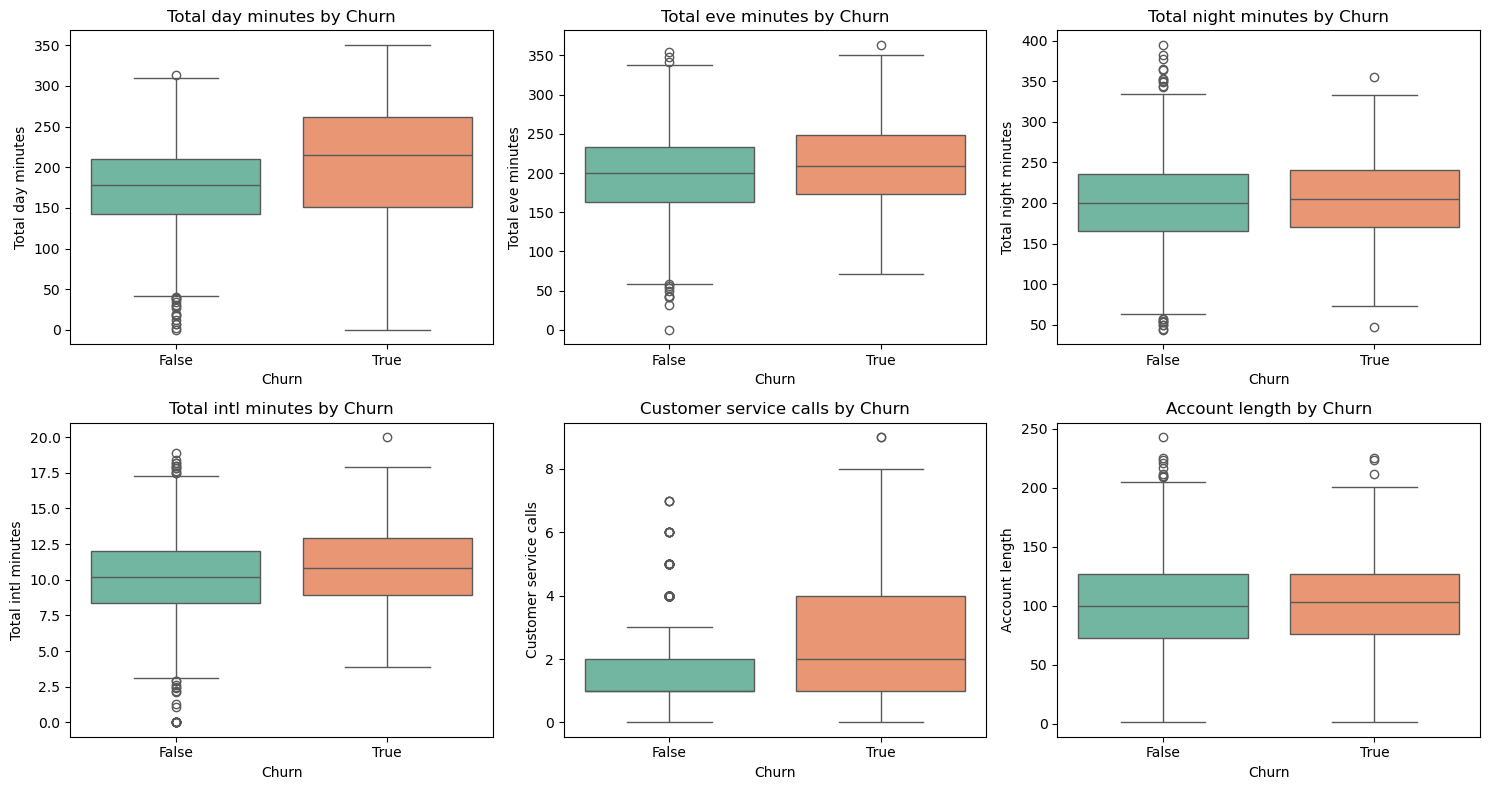

In [17]:
# --- Boxplots (spot outliers, compare against Churn) ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i], palette='Set2', hue='Churn', legend=False)
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

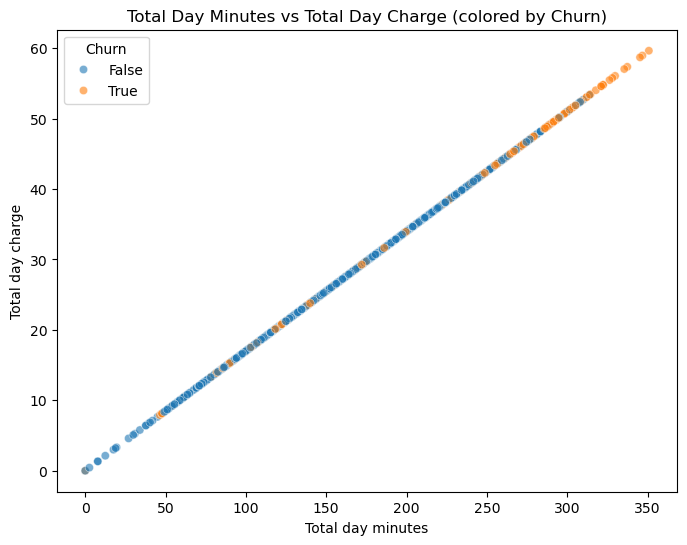

In [14]:
# --- Scatter plot: relationship between two key features ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total day minutes', y='Total day charge', hue='Churn', data=df, alpha=0.6)
plt.title('Total Day Minutes vs Total Day Charge (colored by Churn)')
plt.show()


CORRELATION MATRIX
                        Account length  Area code  Number vmail messages  \
Account length                    1.00      -0.01                  -0.00   
Area code                        -0.01       1.00                  -0.00   
Number vmail messages            -0.00      -0.00                   1.00   
Total day minutes                 0.00      -0.02                   0.02   
Total day calls                   0.04      -0.01                  -0.01   
Total day charge                  0.00      -0.02                   0.02   
Total eve minutes                -0.02       0.00                   0.01   
Total eve calls                   0.02      -0.02                   0.01   
Total eve charge                 -0.02       0.00                   0.01   
Total night minutes              -0.01      -0.00                  -0.00   
Total night calls                -0.02       0.01                   0.01   
Total night charge               -0.01      -0.00                  -

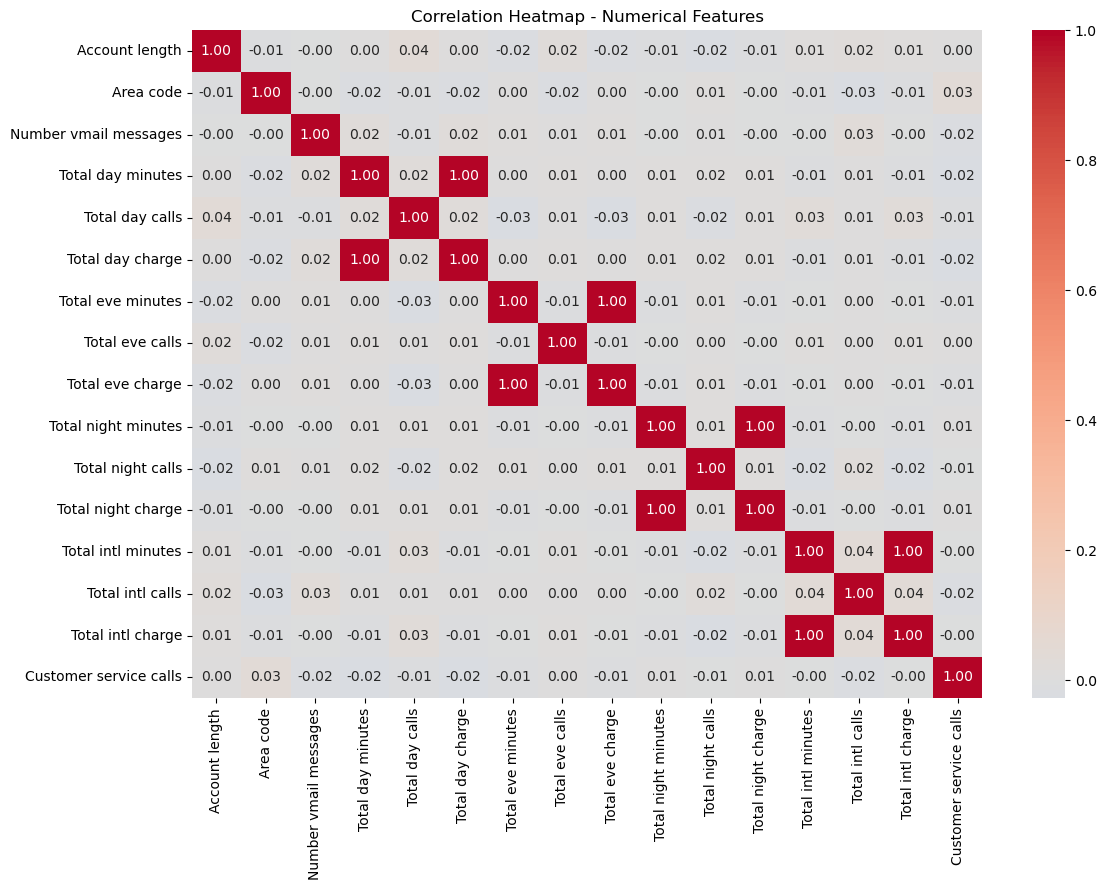

In [15]:
# Correlation matrix (numerical features only) 
corr = df.select_dtypes(include='number').corr()
print("\nCORRELATION MATRIX")
print(corr.round(2))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

In [16]:
# Flag strongest correlations (excluding self-correlation) 
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  
print("\nTop 5 strongest correlations:")
print(corr_pairs.head(10))


Top 5 strongest correlations:
Total day minutes    Total day charge       1.000000
Total day charge     Total day minutes      1.000000
Total eve minutes    Total eve charge       1.000000
Total eve charge     Total eve minutes      1.000000
Total night minutes  Total night charge     0.999999
Total night charge   Total night minutes    0.999999
Total intl minutes   Total intl charge      0.999993
Total intl charge    Total intl minutes     0.999993
Total day calls      Account length         0.038862
Account length       Total day calls        0.038862
dtype: float64


In [18]:
# Level 2 Task 1- Regression Analysis

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [20]:
# Predictor (X) and target (y)
X = df[['Total day minutes']]
y = df['Total day charge']

In [21]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 2132 | Test size: 534


In [22]:
# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions 
y_pred = model.predict(X_test)

# Interpret coefficients 
print(f"\nIntercept: {model.intercept_:.4f}")
print(f"Coefficient (Total day minutes): {model.coef_[0]:.4f}")
print(f"Interpretation: each extra minute of day usage adds ~{model.coef_[0]:.4f} to the day charge")


Intercept: 0.0006
Coefficient (Total day minutes): 0.1700
Interpretation: each extra minute of day usage adds ~0.1700 to the day charge


In [23]:
# Evaluate 
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"\nR-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root MSE: {rmse:.4f}")


R-squared: 1.0000
Mean Squared Error: 0.0000
Root MSE: 0.0029


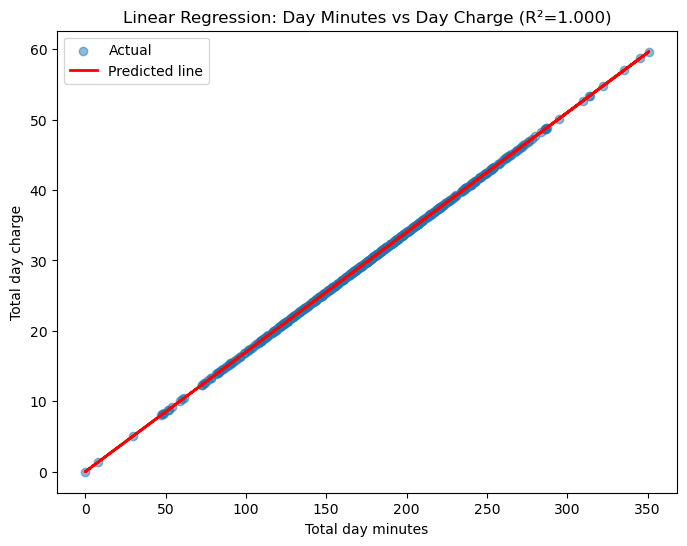

In [24]:
# Visualize fit 
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, alpha=0.5, label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted line')
plt.xlabel('Total day minutes')
plt.ylabel('Total day charge')
plt.title(f'Linear Regression: Day Minutes vs Day Charge (R²={r2:.3f})')
plt.legend()
plt.show()

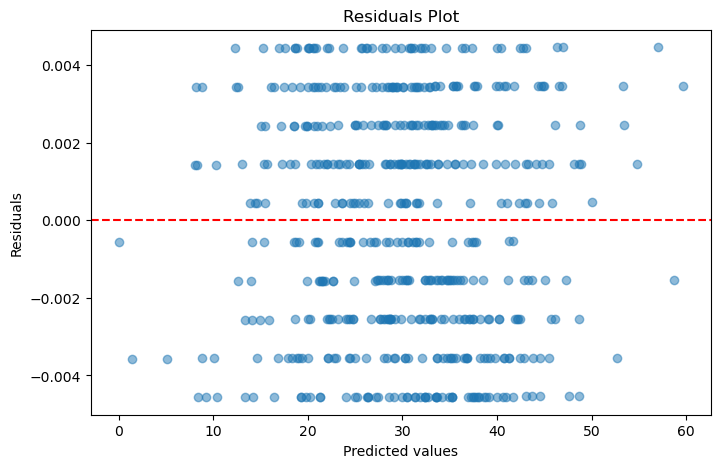

In [25]:
# Residuals plot 
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()

In [ ]:
# Level 2 Task 3- Clustering Analysis (K-Means) 

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [27]:
# Select numerical features for clustering 
# Using usage-related features (drop charge columns since they're just minutes * rate -- redundant with the minutes columns)
cluster_cols = [
    'Account length', 'Number vmail messages',
    'Total day minutes', 'Total eve minutes', 'Total night minutes',
    'Total intl minutes', 'Customer service calls'
]
X = df[cluster_cols]

print("Features used for clustering:", cluster_cols)
print(X.describe())

Features used for clustering: ['Account length', 'Number vmail messages', 'Total day minutes', 'Total eve minutes', 'Total night minutes', 'Total intl minutes', 'Customer service calls']
       Account length  Number vmail messages  Total day minutes  \
count     2666.000000            2666.000000         2666.00000   
mean       100.620405               8.021755          179.48162   
std         39.563974              13.612277           54.21035   
min          1.000000               0.000000            0.00000   
25%         73.000000               0.000000          143.40000   
50%        100.000000               0.000000          179.95000   
75%        127.000000              19.000000          215.90000   
max        243.000000              50.000000          350.80000   

       Total eve minutes  Total night minutes  Total intl minutes  \
count        2666.000000          2666.000000         2666.000000   
mean          200.386159           201.168942           10.237022   
st

In [28]:
# Standardize the dataset 
# K-Means uses distance, so features on different scales (e.g., minutes vs calls) must be scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

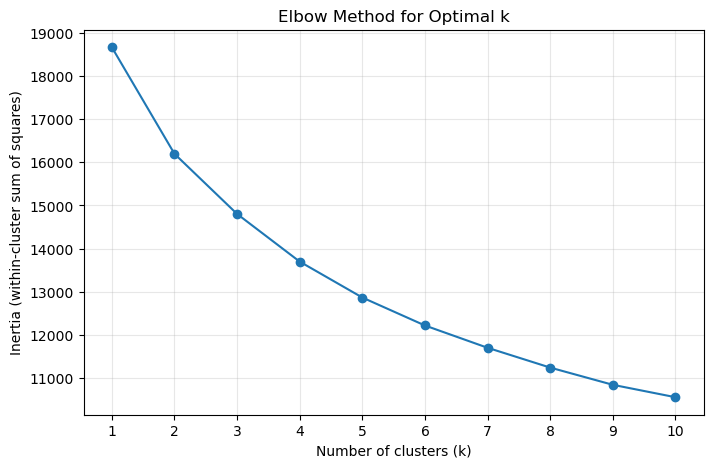

In [29]:
# Elbow method to find optimal k
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.show()

In [30]:
# Fit K-Means with chosen k 
# Inspect the elbow plot above and set k to where the curve visibly bends.
# k=4 is a reasonable starting point for this dataset -- adjust after viewing your plot.
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nCluster sizes (k={optimal_k}):")
print(df['Cluster'].value_counts().sort_index())


Cluster sizes (k=4):
Cluster
0    634
1    851
2    438
3    743
Name: count, dtype: int64


In [31]:
# Cluster profiles (mean of each feature per cluster) 
cluster_profile = df.groupby('Cluster')[cluster_cols].mean().round(2)
print("\nCluster profiles (mean values):")
print(cluster_profile)


Cluster profiles (mean values):
         Account length  Number vmail messages  Total day minutes  \
Cluster                                                             
0                100.36                  30.58             181.94   
1                 80.13                   0.40             199.70   
2                 98.25                   2.53             179.68   
3                125.70                   0.75             154.11   

         Total eve minutes  Total night minutes  Total intl minutes  \
Cluster                                                               
0                   201.00               202.12               10.22   
1                   184.70               217.29               10.31   
2                   196.50               204.28               10.45   
3                   220.11               180.06               10.05   

         Customer service calls  
Cluster                          
0                          1.35  
1                      

In [32]:
# Churn rate per cluster (useful business insight)
churn_by_cluster = df.groupby('Cluster')['Churn'].mean().round(3) * 100
print("\nChurn rate (%) by cluster:")
print(churn_by_cluster)


Churn rate (%) by cluster:
Cluster
0     7.4
1    16.1
2    30.1
3     9.7
Name: Churn, dtype: float64


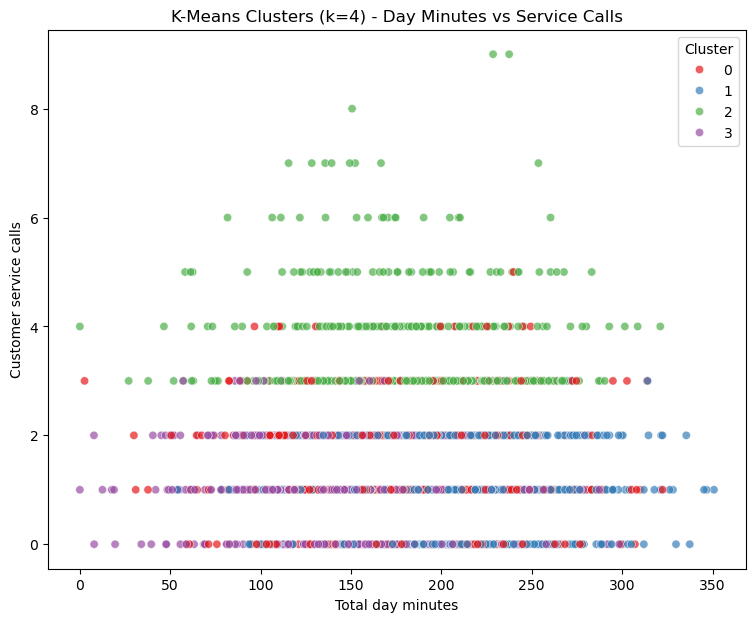

In [33]:
# Visualize clusters (2D scatter using two key features) 
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x='Total day minutes', y='Customer service calls',
    hue='Cluster', data=df, palette='Set1', alpha=0.7
)
plt.title(f'K-Means Clusters (k={optimal_k}) - Day Minutes vs Service Calls')
plt.show()

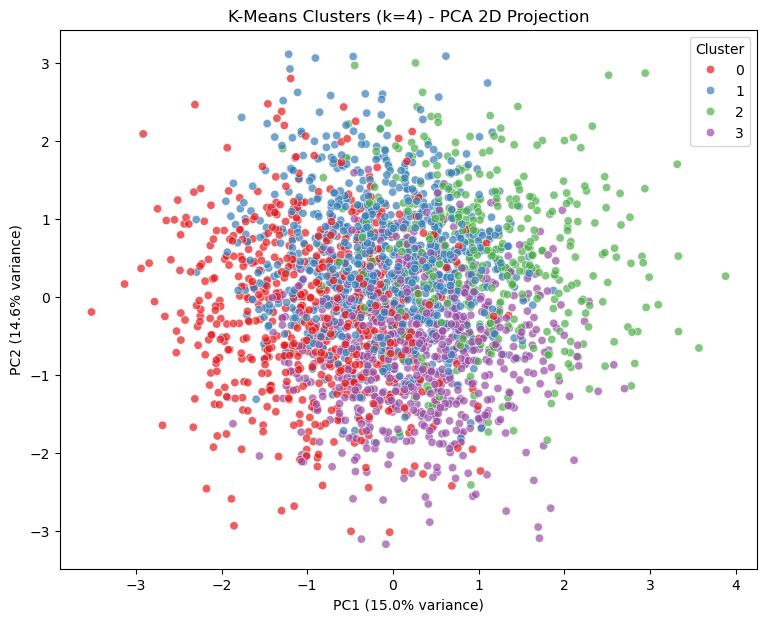


Total variance explained by 2 PCA components: 29.6%


In [34]:
# Visualize clusters via PCA (compress all features into 2D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1', alpha=0.7)
plt.title(f'K-Means Clusters (k={optimal_k}) - PCA 2D Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.show()

print(f"\nTotal variance explained by 2 PCA components: {sum(pca.explained_variance_ratio_)*100:.1f}%")

In [ ]:
# Level 3 Task 1- Predictive Modeling (Classification)

In [35]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [36]:
# Preprocess: handle categorical variables 
df_model = df.copy()
df_model['International plan'] = df_model['International plan'].map({'Yes': 1, 'No': 0})
df_model['Voice mail plan'] = df_model['Voice mail plan'].map({'Yes': 1, 'No': 0})
df_model['Churn'] = df_model['Churn'].astype(int)

# One-hot encode State (many categories, drop_first to avoid multicollinearity)
df_model = pd.get_dummies(df_model, columns=['State'], drop_first=True)

# Drop Area code (not predictive, categorical stored as int)
df_model = df_model.drop(columns=['Area code'])

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print("Feature matrix shape:", X.shape)
print("Churn distribution:\n", y.value_counts(normalize=True))


Feature matrix shape: (2666, 70)
Churn distribution:
 Churn
0    0.854464
1    0.145536
Name: proportion, dtype: float64


In [37]:
# Train/test split (stratify since churn is imbalanced) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
#  Feature scaling (needed for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
#  Train multiple models 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    })
    results_df = pd.DataFrame(results)
print("\nMODEL COMPARISON")
print(results_df.round(4))


MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression    0.8483     0.4651  0.2564    0.3306
1        Decision Tree    0.9101     0.7027  0.6667    0.6842
2        Random Forest    0.9307     0.9767  0.5385    0.6942


In [45]:
# Hyperparameter tuning: Random Forest via GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\nBest parameters:", grid_search.best_params_)
print("Best cross-val F1 score:", round(grid_search.best_score_, 4))



Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-val F1 score: 0.7151


In [41]:
# Evaluate tuned model on test set 
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\nTUNED RANDOM FOREST - TEST SET PERFORMANCE")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))


TUNED RANDOM FOREST - TEST SET PERFORMANCE
              precision    recall  f1-score   support

    No Churn       0.94      1.00      0.97       456
       Churn       1.00      0.62      0.76        78

    accuracy                           0.94       534
   macro avg       0.97      0.81      0.87       534
weighted avg       0.95      0.94      0.94       534



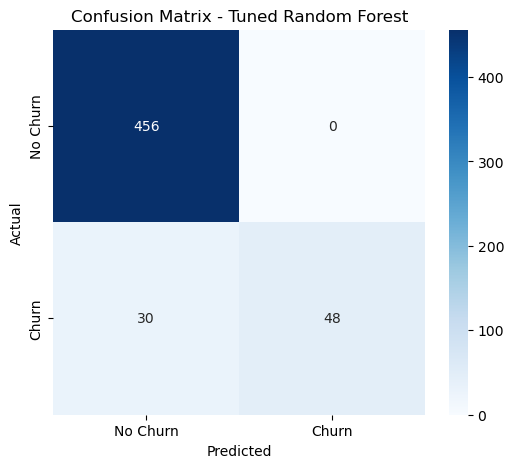

In [42]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

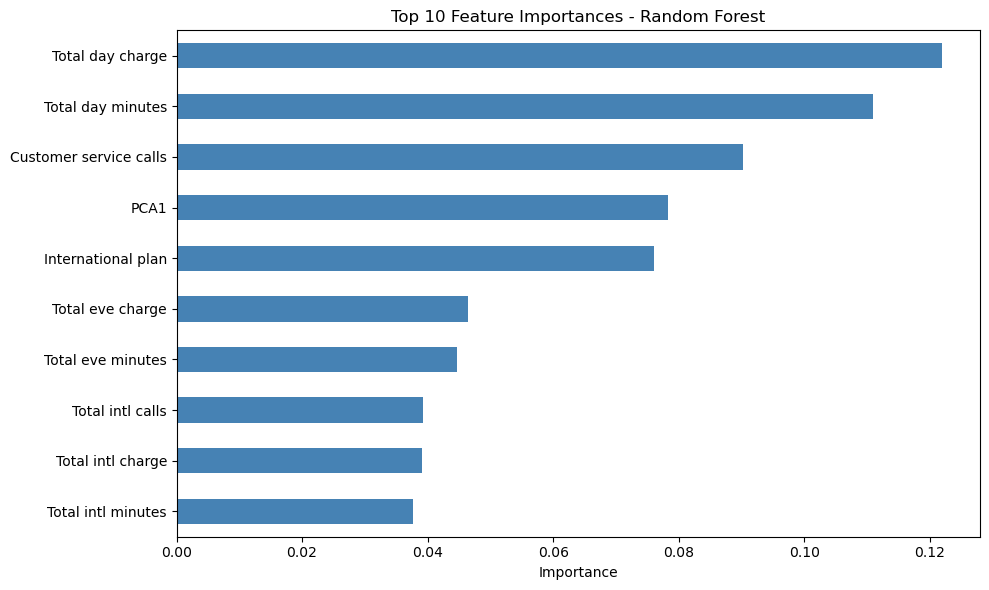

In [43]:
# Feature importance 
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [44]:
print("\nTop 10 most important features:")
print(importances)


Top 10 most important features:
Total day charge          0.121925
Total day minutes         0.110926
Customer service calls    0.090245
PCA1                      0.078327
International plan        0.076131
Total eve charge          0.046380
Total eve minutes         0.044721
Total intl calls          0.039313
Total intl charge         0.039074
Total intl minutes        0.037677
dtype: float64
